# Packages and Libararies

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets, transforms,  models
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix

from tqdm.auto import tqdm
import requests
from pathlib import Path
from timeit import default_timer as timer
import random

print(torch.__version__)
print(torchvision.__version__)


2.11.0+cu128
0.26.0+cu128


In [2]:
def print_train_time( start: int,
                      end: int,
                      device: torch.device = None):
    total_time = end - start
    print(f'train time on {device}: {total_time:.2f} seconds')
    return total_time


start_time = timer()
###
###
end_time = timer()

print_train_time(start = start_time, end = end_time, device = 'cpu')

train time on cpu: 0.00 seconds


2.422299996851507e-05

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Data Preparation

## Data Extraction

In [4]:
train_set = datasets.CIFAR10(
    root= "/content/drive/MyDrive/Datasets/CIFAR10",
    train = True ,
    transform = ToTensor(),
    target_transform = None ,
    download = False

)

test_set = datasets.CIFAR10(
    root = "/content/drive/MyDrive/Datasets/CIFAR10",
    train = False,
    transform = ToTensor(),
    target_transform = None,
    download = False

)

## Train-set and Test-set Investigation

In [5]:
len(train_set), len(test_set)

(50000, 10000)

In [6]:
print(f'{train_set}\n')
print('===========================')
print(f'{train_set[0]}\n')
print('===========================')
print(f'image: {train_set[0][0]}\n')
print('===========================')
print(f'label: {train_set[0][1]}')

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /content/drive/MyDrive/Datasets/CIFAR10
    Split: Train
    StandardTransform
Transform: ToTensor()

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 

In [7]:

idx = torch.randint(0, len(train_set), size = ())
image, label = train_set[idx]

print(f'label: {label}')
print(f'Image: {image}')
print(f'Image Shape: {image.shape}')


label: 9
Image: tensor([[[0.1843, 0.1529, 0.1529,  ..., 0.1843, 0.1255, 0.0902],
         [0.1686, 0.1529, 0.1451,  ..., 0.2196, 0.1647, 0.1490],
         [0.1255, 0.1137, 0.1020,  ..., 0.1843, 0.1059, 0.1294],
         ...,
         [0.3804, 0.4235, 0.4118,  ..., 0.4039, 0.4039, 0.3922],
         [0.3804, 0.3843, 0.3608,  ..., 0.6118, 0.5961, 0.5686],
         [0.3922, 0.3961, 0.4157,  ..., 0.5922, 0.6118, 0.6039]],

        [[0.2157, 0.1843, 0.1843,  ..., 0.2196, 0.1608, 0.1255],
         [0.2000, 0.1843, 0.1765,  ..., 0.2510, 0.1961, 0.1804],
         [0.1569, 0.1451, 0.1333,  ..., 0.2157, 0.1412, 0.1608],
         ...,
         [0.4667, 0.5098, 0.4902,  ..., 0.4941, 0.4980, 0.4902],
         [0.4706, 0.4706, 0.4471,  ..., 0.7020, 0.6863, 0.6627],
         [0.4863, 0.4863, 0.5059,  ..., 0.6706, 0.6902, 0.6824]],

        [[0.1647, 0.1333, 0.1333,  ..., 0.1412, 0.0902, 0.0549],
         [0.1490, 0.1333, 0.1255,  ..., 0.1882, 0.1373, 0.1255],
         [0.1059, 0.0941, 0.0824,  ..., 0.

In [8]:
class_names = train_set.classes
class_to_idx = train_set.class_to_idx
targets = train_set.targets

print(class_names)
print(class_to_idx)
print(targets)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
[6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1

## Visualize Images and Labels

In [9]:
print(image.shape)    # -> working with torch
print(image.permute(1,2,0).numpy().shape)   # working with -> matplit

torch.Size([3, 32, 32])
(32, 32, 3)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

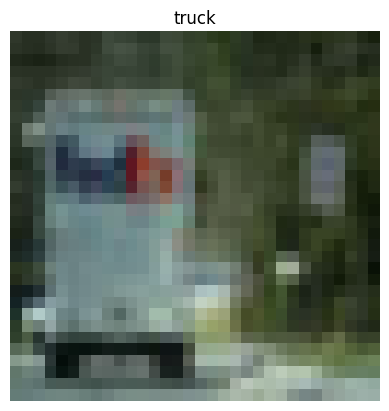

In [10]:
img_np = image.permute(1, 2, 0).numpy()
plt.imshow(img_np)
plt.title(class_names[label])
plt.axis(False)

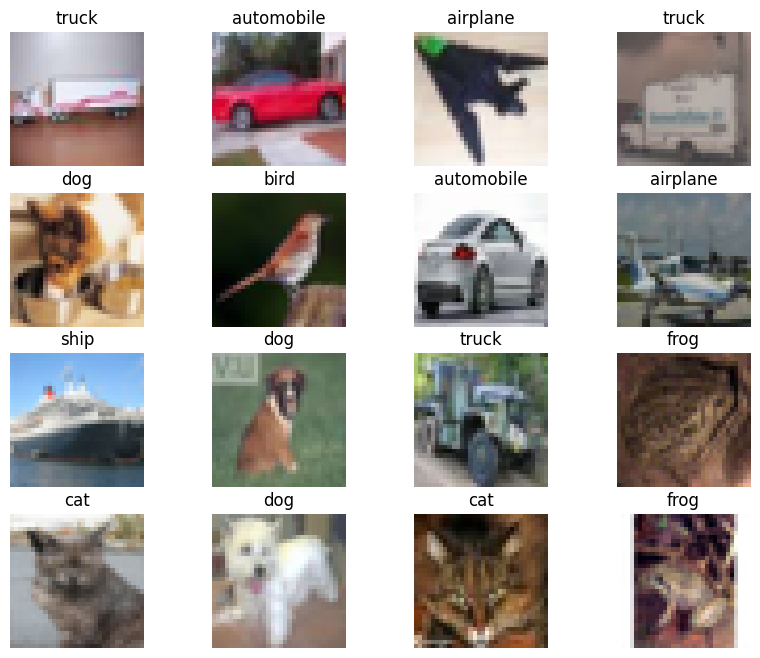

In [11]:
def plot_images_from_dataset(data, class_names):
    plt.subplots(nrows =4, ncols =4, figsize=(10 , 8))
    for i in range(0, 4*4):
        num = torch.randint(0, len(data), size = ())
        image_sample, label_sample = data[num]
        permuted_image_sample = image_sample.permute(1,2,0).numpy()
        plt.subplot(4,4,i+1)
        plt.imshow(permuted_image_sample)
        plt.title(class_names[label_sample])
        plt.axis(False)

plot_images_from_dataset(data = train_set, class_names = class_names)

## Batching the Dataset

In [12]:

train_loader = DataLoader(dataset = train_set,
                          batch_size  = 32,
                          shuffle = True)

test_loader = DataLoader(dataset= test_set,
                         batch_size = 32,
                         shuffle = False)


In [13]:
print(f'Train-loader length: {len(train_loader)}, Test-loader length: {len(test_loader)}')


Train-loader length: 1563, Test-loader length: 313


In [14]:
train_feature_batch, train_label_batch = next(iter(train_loader))
print('Feature-batch_shape: ', train_feature_batch.shape)
print('Label-batch-shape: ', train_label_batch.shape)


Feature-batch_shape:  torch.Size([32, 3, 32, 32])
Label-batch-shape:  torch.Size([32])


## Visualize Samples from Batches

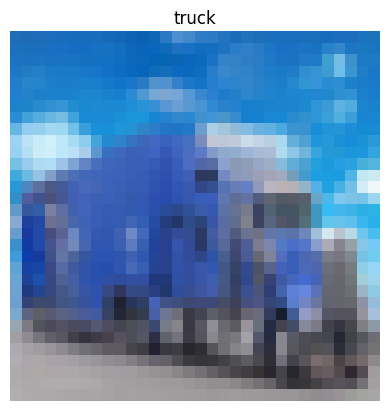

In [15]:

def plot_sample_from_batch(data, class_names):

    batch_of_images, batch_of_labels = next(iter(data))
    rand_num = torch.randint(0 , len(batch_of_images), size = ())
    image_sample, label_sample = batch_of_images[rand_num], batch_of_labels[rand_num]
    permuted_image_sample = image_sample.permute(1,2,0).numpy()
    plt.imshow(permuted_image_sample)
    plt.title(class_names[label_sample])
    plt.axis(False)

plot_sample_from_batch(data = train_loader, class_names = class_names )

## Data Processing with `nn.layers`

In [16]:
train_image_batch , train_label_batch = next(iter(train_loader))
x = train_image_batch[0]
flatten_model = nn.Flatten()
output = flatten_model(x)

print(f'{x.shape} -> {output.shape}')


torch.Size([3, 32, 32]) -> torch.Size([3, 1024])


# Model0 Base-Line

## Create the Model

In [17]:
class CIFAR10ModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= input_shape,
                      out_features= hidden_units),
            nn.Linear(in_features= hidden_units,
                      out_features= output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


In [18]:
model_0 = CIFAR10ModelV0(input_shape = 3*32*32,
                          hidden_units = 10,
                          output_shape=(len(class_names))).to(device)
print(model_0)

CIFAR10ModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)


## Investigate the Model

In [19]:
# Make prediction with untrained model
torch.random.manual_seed(42)
dummy = torch.rand([1,3,32,32]).to(device)  # a random image from the batch
pred = model_0(dummy)
print('Pred-Probs:', pred)  # predicted probabilities
print('Pred-Labels:', torch.argmax(pred, dim = 1)) # predicted labels

Pred-Probs: tensor([[-0.0355,  0.0751,  0.3858, -0.0977,  0.1480,  0.3887,  0.1019,  0.3897,
         -0.3678, -0.0331]], device='cuda:0', grad_fn=<AddmmBackward0>)
Pred-Labels: tensor([7], device='cuda:0')


In [20]:
# Model Weights
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0166,  0.0166, -0.0173,  ..., -0.0104,  0.0162, -0.0151],
                      [-0.0085, -0.0106,  0.0025,  ..., -0.0070,  0.0154,  0.0136],
                      [ 0.0165, -0.0174,  0.0148,  ..., -0.0179,  0.0073, -0.0030],
                      ...,
                      [ 0.0011, -0.0083, -0.0054,  ..., -0.0119,  0.0060,  0.0043],
                      [ 0.0147, -0.0179, -0.0133,  ..., -0.0115,  0.0111,  0.0009],
                      [ 0.0024, -0.0104, -0.0162,  ..., -0.0009,  0.0173,  0.0124]],
                     device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([-0.0019, -0.0097,  0.0121,  0.0145, -0.0065,  0.0105,  0.0003,  0.0044,
                       0.0069, -0.0016], device='cuda:0')),
             ('layer_stack.2.weight',
              tensor([[ 0.2788, -0.1392,  0.2593,  0.1082,  0.1048, -0.1965, -0.2916,  0.0252,
                       -0.1743, -0.0637],
                      [-0

## Loss Function, Optimizer and Accuracy Function

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                            lr = 0.001)

In [22]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## Train the model

In [23]:

# Set the seed
torch.manual_seed(42)
# Start training time
start_train_on_gpu = timer()

batchs  = 15
# Training and Testing loop
for batch in tqdm(range(batchs)):
    print(f'Epoch: {batch}\n------')

    ###TRAINING LOOP
    train_loss = 0
    #Loop through the trainig batches
    for batch, (X, y) in enumerate(train_loader):
        # 0. Push tensors to GPU
        X, y = X.to(device), y.to(device)

        model_0.train()
        # 1. Pass forward
        y_pred = model_0(X)
        # 2. Calculate loss per batch
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() # Accumelate the loss value in batches
        # 3. Set optimizer grad to zero
        optimizer.zero_grad()
        # 4. Loss backward
        loss.backward()
        # 5. Taking steps with optimizer (update the parameters per epoch)
        optimizer.step()

        if batch % 400 == 0:
            print(f'Looked at {batch * len(X)} / {len(train_loader.dataset)} samples')
    # Calculate train loss average per batch
    train_loss /= len(train_loader)

    ###Tesing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            # 1. Forward pass
            y_pred_test = model_0(X_test)
            # 2. Calculate Loss (accumately)
            test_loss += loss_fn(y_pred_test, y_test).item()
            # 3. Caculate accuracy (accumately)
            test_acc += accuracy_fn(
                y_true = y_test,
                y_pred = y_pred_test.argmax(dim = 1)
            )
        #Test Loss average per epoch
        test_loss /=  len(test_loader)
        #Test accuracy average per epoch
        test_acc /= len(test_loader)

    print(f'Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

stop_train_on_gpu = timer()

total_train_time_model_0 = print_train_time(start = start_train_on_gpu,
                                            end= stop_train_on_gpu,
                                            device = str(next(model_0.parameters()).device))


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train loss: 1.9159 | Test loss: 1.8219 | Test Acc: 35.14%
Epoch: 1
------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train loss: 1.8093 | Test loss: 1.7837 | Test Acc: 37.94%
Epoch: 2
------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train loss: 1.7828 | Test loss: 1.7997 | Test Acc: 36.42%
Epoch: 3
------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train loss: 1.7665 | Test loss: 1.7698 | Test Acc: 38.16%
Epoch: 4
------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train loss: 1.7572 | Test loss: 1.8514 | Test Acc: 35.53%
Epoch: 5
-

In [24]:
# Evaluate the model on the test-set
def model_eval(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: torch.nn.Module,
               device = None):
    total_loss, total_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            batch_loss = loss_fn(y_pred,y).item()
            total_loss += batch_loss
            acc = accuracy_fn(y_true = y,
                              y_pred = y_pred.argmax(dim = 1))
            total_acc += acc

        total_loss /= len(data_loader)
        total_acc /= len(data_loader)


    return {"model_name": model.__class__.__name__,
        "model_loss": total_loss,
        "model_acc": total_acc
        }


In [25]:
model_0_results = model_eval(model = model_0,
                             data_loader = test_loader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn,
                             device = device)

In [26]:
model_0_results

{'model_name': 'CIFAR10ModelV0',
 'model_loss': 1.7415563092825892,
 'model_acc': 39.566693290734825}

# Model1 Non-Linearity


## Create the Model

In [27]:
class ModelCIFAR10V1(nn.Module):
    def __init__(self,input_shape, hidden_units, output_shape):
        super().__init__()

        self.stacked_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features = output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.stacked_layers( x)

In [28]:
model_1 = ModelCIFAR10V1(input_shape= 3*32*32 ,
                         hidden_units = 30,
                         output_shape=10).to(device)
model_1

ModelCIFAR10V1(
  (stacked_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=30, bias=True)
    (2): ReLU()
    (3): Linear(in_features=30, out_features=10, bias=True)
    (4): ReLU()
  )
)

## Loss Function and Optimizer

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.001)

## Train the Model

In [30]:
def Train_step(model: nn.Module,
               data_loader,
               loss_fn,
               optimizer,
               accuracy_fn,
               device):

    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        model.train()

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        accuracy = accuracy_fn(y_true = y,
                               y_pred = y_pred.argmax(dim = 1))
        train_acc += accuracy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f'Looked at {batch * len(X)} / {len(train_loader.dataset)} samples')

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%')

def Test_step(model,
              data_loader,
              loss_fn,
              accuracy_fn,
              device):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in data_loader:

            X_test, y_test = X_test.to(device), y_test.to(device)

            y_pred = model(X_test)

            loss = loss_fn(y_pred, y_test)
            test_loss += loss.item()

            accuracy = accuracy_fn(y_true = y_test,
                                   y_pred = y_pred.argmax(dim = 1))
            test_acc += accuracy


        test_loss/=len(data_loader)
        test_acc/=len(data_loader)
        print(f'Test Loss: {test_loss:.4f} | Test_accuracy: {test_acc:.2f}%')



In [31]:
start_train_on_gpu = timer()

epochs = 30
for epoch in tqdm(range(epochs)):
    print(f'Epochs: {epoch}\n-------')

    Train_step(model_1,
               train_loader,
               loss_fn,
               optimizer,
               accuracy_fn ,
               device)

    Test_step(model_1,
              test_loader,
              loss_fn,
              accuracy_fn,
              device)

stop_train_on_gpu = timer()

total_train_time_model_1 = print_train_time(start= start_train_on_gpu,
                 end = stop_train_on_gpu,
                device = str(next(model_1.parameters()).device))


  0%|          | 0/30 [00:00<?, ?it/s]

Epochs: 0
-------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train Loss: 2.2453 | Train Accuracy: 19.83%
Test Loss: 2.1942 | Test_accuracy: 22.68%
Epochs: 1
-------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train Loss: 2.1554 | Train Accuracy: 24.87%
Test Loss: 2.1197 | Test_accuracy: 26.68%
Epochs: 2
-------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train Loss: 2.0927 | Train Accuracy: 28.37%
Test Loss: 2.0661 | Test_accuracy: 30.82%
Epochs: 3
-------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 25600 / 50000 samples
Looked at 38400 / 50000 samples
Train Loss: 2.0463 | Train Accuracy: 30.48%
Test Loss: 2.0246 | Test_accuracy: 32.06%
Epochs: 4
-------
Looked at 0 / 50000 samples
Looked at 12800 / 50000 samples
Looked at 

In [32]:
def model_eval(model,
               data_loader,
               loss_fn,
               accuracy_fn,
               device):

    total_loss, total_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            batch_loss = loss_fn(y_pred , y )
            total_loss += batch_loss.item()
            batch_acc = accuracy_fn(y_true = y,
                              y_pred = y_pred.argmax(dim =1))
            total_acc += batch_acc

        total_loss /= len(data_loader)
        total_acc /= len(data_loader)

    return {'model_name': model.__class__.__name__,
            'model_loss': total_loss,
            'model_acc': total_acc}





In [33]:
model_1_results = model_eval(model = model_1 ,
                             data_loader = test_loader ,
                             loss_fn = loss_fn ,
                             accuracy_fn=accuracy_fn,
                             device = device)


In [34]:
model_1_results

{'model_name': 'ModelCIFAR10V1',
 'model_loss': 1.6898579327062295,
 'model_acc': 41.23402555910543}

# Model2 Convnet

## Create the model

In [47]:
class ModelCIFAR10V2(nn.Module):
    def __init__(self, input_shape=3, hidden_units=32, output_shape=10):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(hidden_units*2, hidden_units*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),  # Dropout before linear
            nn.Linear(hidden_units*4 * 4 * 4, output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)
        return x

In [48]:
model_2 = ModelCIFAR10V2(input_shape = 3,
                         hidden_units = 32,
                         output_shape = 10).to(device)

model_2

ModelCIFAR10V2(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fa

## Loss Function and Optimizer

In [49]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_2.parameters(),
                             lr = 0.001)


## Train the model

In [50]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               optimizer,#: torch.optim.optimizer,
               loss_fn: torch.nn.Module,
               accuracy_fn,
                 device):
    train_loss, train_acc = 0, 0
    for batch, (X_train, y_train) in enumerate(data_loader):

        X_train, y_train = X_train.to(device), y_train.to(device)
        model.train()

        y_pred = model(X_train)

        loss = loss_fn(y_pred, y_train)
        train_loss += loss.item()

        acc = accuracy_fn(y_true =y_train,
                          y_pred = y_pred.argmax(dim = 1))
        train_acc += acc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f'Looked at {batch * len(X_train)} / {len(data_loader)} samples')

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f'Train Loss: {train_loss:.4f} | Train accuracy: {train_acc:.2f}%')


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in data_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            y_pred = model(X_test)
            loss = loss_fn(y_pred, y_test)
            test_loss += loss.item()
            accuracy = accuracy_fn(y_true = y_test,
                                   y_pred = y_pred.argmax(dim = 1))
            test_acc += accuracy


        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

    print( f'Test Loss:  {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%')

In [51]:
start_trainig_on_gpu = timer()

batches = 20
for batch in tqdm(range(batches)):
    print(f'batch: {batch}\n------')
    train_step(model_2,
               train_loader,
               optimizer,
               loss_fn,
               accuracy_fn,
               device)
    test_step(model_2,
              test_loader,
              loss_fn,
              accuracy_fn,
              device)

stop_training_on_gpu = timer()

total_train_time_model_2 = print_train_time(start = start_trainig_on_gpu,
                                        end = stop_training_on_gpu,
                                            device= device)


  0%|          | 0/20 [00:00<?, ?it/s]

batch: 0
------
Looked at 0 / 1563 samples
Looked at 12800 / 1563 samples
Looked at 25600 / 1563 samples
Looked at 38400 / 1563 samples
Train Loss: 1.3105 | Train accuracy: 53.85%
Test Loss:  1.0170 | Test Accuracy: 64.24%
batch: 1
------
Looked at 0 / 1563 samples
Looked at 12800 / 1563 samples
Looked at 25600 / 1563 samples
Looked at 38400 / 1563 samples
Train Loss: 0.8706 | Train accuracy: 69.69%
Test Loss:  0.7780 | Test Accuracy: 72.78%
batch: 2
------
Looked at 0 / 1563 samples
Looked at 12800 / 1563 samples
Looked at 25600 / 1563 samples
Looked at 38400 / 1563 samples
Train Loss: 0.7369 | Train accuracy: 74.21%
Test Loss:  0.7067 | Test Accuracy: 75.68%
batch: 3
------
Looked at 0 / 1563 samples
Looked at 12800 / 1563 samples
Looked at 25600 / 1563 samples
Looked at 38400 / 1563 samples
Train Loss: 0.6525 | Train accuracy: 77.36%
Test Loss:  0.6402 | Test Accuracy: 78.28%
batch: 4
------
Looked at 0 / 1563 samples
Looked at 12800 / 1563 samples
Looked at 25600 / 1563 samples
Loo

In [52]:
# Create a dummy tensor to pass through the convolutional blocks
dummy_tensor = torch.randn(1, 3, 32, 32).to(device) # Batch size, channels, height, width

# Instantiate the model with the corrected input shape
model_2_test = ModelCIFAR10V2(input_shape=3,
                              hidden_units=15,
                              output_shape=10).to(device)

# Pass the dummy tensor through the convolutional blocks
output_of_conv_blocks = model_2_test.block_2(model_2_test.block_1(dummy_tensor))

# Print the shape of the output tensor
print(output_of_conv_blocks.shape)

# Calculate the expected input features for the linear layer
expected_in_features = output_of_conv_blocks.shape[1] * output_of_conv_blocks.shape[2] * output_of_conv_blocks.shape[3]
print(f"Expected in_features for the linear layer: {expected_in_features}")

torch.Size([1, 30, 8, 8])
Expected in_features for the linear layer: 1920


In [53]:
#Model Evaluation
def eval_model(model,
               data_loader,
               loss_fn,
               accuracy_fn,
               device):

    total_loss, total_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            batch_loss = loss_fn(y_pred, y)
            total_loss += batch_loss.item()

            batch_acc = accuracy_fn(y_true = y,
                              y_pred = y_pred.argmax(dim = 1))
            total_acc += batch_acc


        total_loss /= len(data_loader)
        total_acc /= len(data_loader)

    return {'model_name':model.__class__.__name__,
            'model_loss': total_loss,
            'model_acc': total_acc}


In [54]:
model_2_results = eval_model(model_2,
                             test_loader ,
                             loss_fn ,
                             accuracy_fn,
                             device)
model_2_results

{'model_name': 'ModelCIFAR10V2',
 'model_loss': 0.5226938188694917,
 'model_acc': 84.185303514377}

# Going through CNN Layers

### Conv2d

In [55]:
images  = torch.randn(size = (32, 3, 32,32)) # one batch of 32 numbers of photos
sample_image = images[0]  # one image from that batch
print(images.shape)
print(sample_image.shape)


torch.Size([32, 3, 32, 32])
torch.Size([3, 32, 32])


In [56]:
conv_layer = nn.Conv2d(in_channels = 3 ,
          out_channels = 10,
          kernel_size =3 ,
          stride = 1,
          padding =0 )
conv_layer_output  = conv_layer(sample_image.squeeze())
conv_layer_output.shape

torch.Size([10, 30, 30])

In [57]:
maxpooling_layer = nn.MaxPool2d(kernel_size = 2)
maxpool_output = maxpooling_layer(conv_layer_output)
maxpool_output.shape

torch.Size([10, 15, 15])

### MaxPool2d

In [58]:
random_tensor = torch.randn(size = (1,1,4,4))
maxpool_output = nn.MaxPool2d(kernel_size = 2)(random_tensor)
maxpool_output.shape

torch.Size([1, 1, 2, 2])

# Compare Results

In [59]:
compare_results = pd.DataFrame([
    model_0_results,
    model_1_results,
    model_2_results
])



In [60]:
compare_results['training_time'] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,CIFAR10ModelV0,1.741556,39.566693,153.442253
1,ModelCIFAR10V1,1.689858,41.234026,304.509723
2,ModelCIFAR10V2,0.522694,84.185304,284.633586


Text(0, 0.5, 'Model')

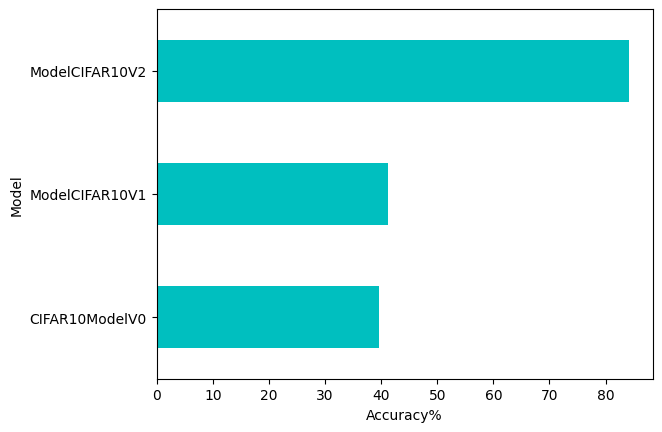

In [61]:
compare_results.set_index('model_name')['model_acc'].plot(kind = 'barh', color = 'c')
plt.xlabel('Accuracy%')
plt.ylabel('Model')

#Make Prediction with the best Model

In [62]:
# Test set investigation
print(test_loader)
print('------')
print(test_set)
print('------')
print('image: ', test_set[0][0])  # First sample image
print('------')
print('label: ', test_set[0][1])  # First sample label
print('------')

img, label = test_set[1] # Seocnd sample
print('image shape: ', img.shape)


------
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Datasets/CIFAR10
    Split: Test
    StandardTransform
Transform: ToTensor()
------
image:  tensor([[[0.6196, 0.6235, 0.6471,  ..., 0.5373, 0.4941, 0.4549],
         [0.5961, 0.5922, 0.6235,  ..., 0.5333, 0.4902, 0.4667],
         [0.5922, 0.5922, 0.6196,  ..., 0.5451, 0.5098, 0.4706],
         ...,
         [0.2667, 0.1647, 0.1216,  ..., 0.1490, 0.0510, 0.1569],
         [0.2392, 0.1922, 0.1373,  ..., 0.1020, 0.1137, 0.0784],
         [0.2118, 0.2196, 0.1765,  ..., 0.0941, 0.1333, 0.0824]],

        [[0.4392, 0.4353, 0.4549,  ..., 0.3725, 0.3569, 0.3333],
         [0.4392, 0.4314, 0.4471,  ..., 0.3725, 0.3569, 0.3451],
         [0.4314, 0.4275, 0.4353,  ..., 0.3843, 0.3725, 0.3490],
         ...,
         [0.4863, 0.3922, 0.3451,  ..., 0.3804, 0.2510, 0.3333],
         [0.4549, 0.4000, 0.3333,  ..., 0.3216, 0.3216, 0.2510],
         [0.4196, 0.4118, 0.3490,  ..., 0.3020, 0.3294, 0.2627]],


Image shape:  torch.Size([3, 32, 32])
label:  2


Text(0.5, 1.0, 'bird')

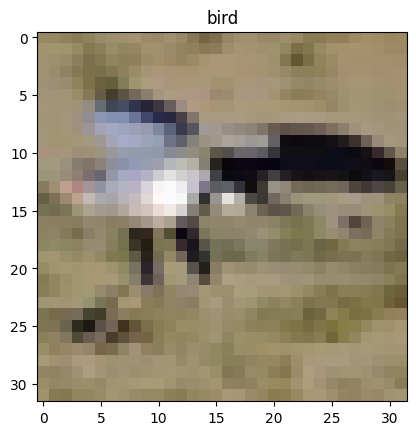

In [63]:
# Random data visualization
img_samples = []
label_samples = []

for img, label in random.sample(list(test_set), k = 9):
    img_samples.append(img)
    label_samples.append(label)

print('Image shape: ', img_samples[5].shape)
print('label: ', label_samples[5])

image = img_samples[5].permute(1,2,0).numpy()
label = label_samples[5]
plt.imshow(image)
plt.title(class_names[label])

In [64]:
def make_prediction(model, data):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:

            # Assuming sample is a list where the first element is the image tensor
            img_tensor = sample[0].to(device)

            pred_logits = model(img_tensor)

            pred_prob = torch.softmax(pred_logits, dim=1)

            pred_probs.append(pred_prob)

    return torch.cat(pred_probs) # Concatenate the predictions

In [65]:
pred_probs = make_prediction(model= model_2,
                             data = test_loader)
print(pred_probs[:10]) # Made prob predictions for first 10 samples

pred_classes = pred_probs.argmax(dim = 1) # Convert predictions to labels
print(pred_classes)

tensor([[7.1867e-06, 1.3728e-06, 2.4468e-05, 9.9218e-01, 9.5671e-06, 5.5035e-03,
         2.2421e-03, 9.7029e-06, 1.8209e-05, 4.1621e-06],
        [5.8852e-06, 1.5138e-02, 1.0792e-11, 9.9489e-12, 1.5208e-16, 2.6611e-16,
         1.0125e-09, 6.4776e-14, 9.8486e-01, 1.6098e-07],
        [5.4149e-05, 2.0255e-03, 6.5967e-08, 2.2187e-07, 1.5953e-10, 7.5205e-10,
         1.1560e-08, 1.2032e-09, 9.9788e-01, 3.7332e-05],
        [8.3059e-01, 4.2114e-04, 3.5153e-05, 4.0544e-03, 3.0046e-07, 6.7951e-07,
         4.9857e-07, 2.8551e-07, 1.6461e-01, 2.8276e-04],
        [1.6430e-07, 3.3878e-04, 1.5554e-03, 1.0307e-04, 1.9547e-05, 1.0783e-07,
         9.9782e-01, 1.6841e-08, 1.6290e-04, 1.8463e-06],
        [4.1954e-07, 5.9708e-07, 2.5701e-07, 1.8775e-04, 8.2873e-06, 2.1214e-04,
         9.9936e-01, 9.7246e-07, 1.2330e-06, 2.2364e-04],
        [3.7047e-11, 9.9844e-01, 4.7528e-15, 3.8707e-11, 1.2658e-13, 2.7536e-10,
         5.3231e-13, 1.2705e-09, 1.8781e-12, 1.5577e-03],
        [3.3742e-02, 2.0130

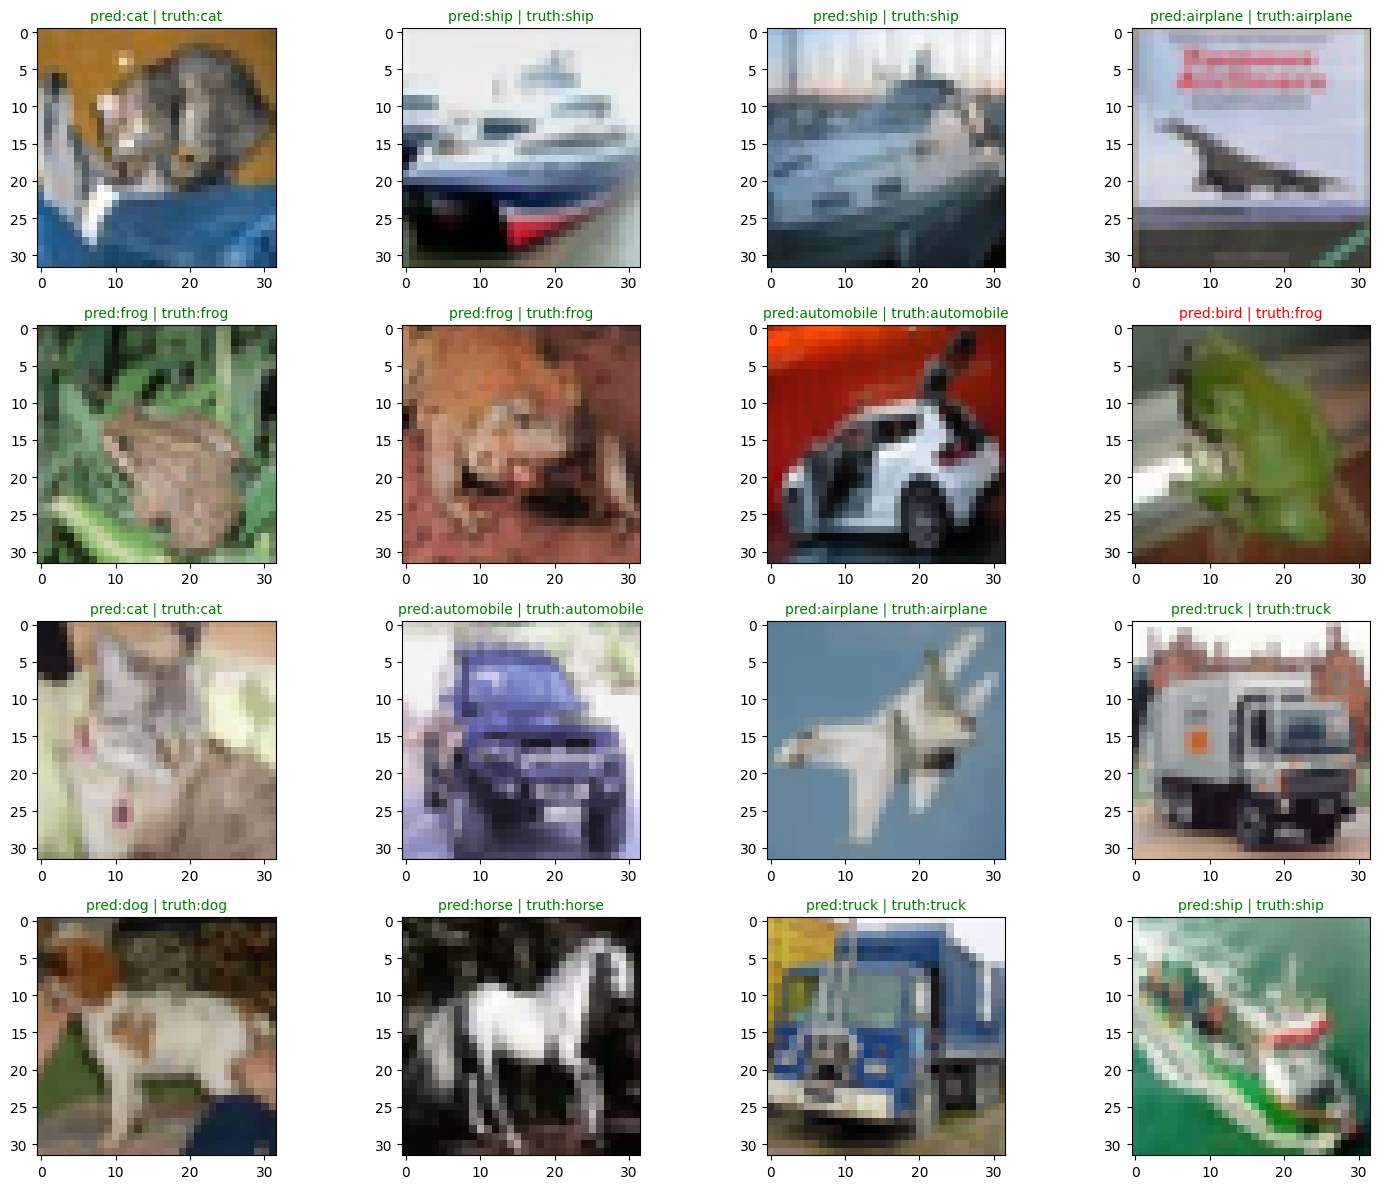

In [66]:

def plot_predictions(data, class_names, pred_classes):
    fig, axes= plt.subplots(nrows = 4, ncols = 4, figsize = (15,12) )
    axes = axes.flatten()

    for (i, sample), axe in zip(enumerate(data), axes):
        img = sample[0]
        img =  img.permute(1,2,0).numpy()
        axe.imshow(img)

        truth_label = class_names[sample[1]]
        pred_label = class_names[pred_classes[i]]

        Text= f'pred:{pred_label} | truth:{truth_label}'

        if truth_label == pred_label:
            axe.set_title(Text, fontsize = 10, c = 'g' )
        else:
            axe.set_title(Text, fontsize = 10, c = 'r' )


    plt.tight_layout()
    plt.show()


plot_predictions(data = test_set,
                 class_names = class_names ,
                 pred_classes = pred_classes )



#Confusion Matrix

In [67]:
# Make Prediction
model_pred = []
y_true = []
model_2.eval()
with torch.inference_mode():
    for X,y in tqdm(test_loader):
        X,y = X.to(device),y.to(device)
        y_true.append(y)
        pred_logits = model_2(X)
        pred_label = torch.softmax(pred_logits, dim = 0).argmax(dim = 1)
        model_pred.append(pred_label)


y_pred_tensor = torch.cat(model_pred).to(device)


  0%|          | 0/313 [00:00<?, ?it/s]

<Axes: >

<Figure size 3000x1000 with 0 Axes>

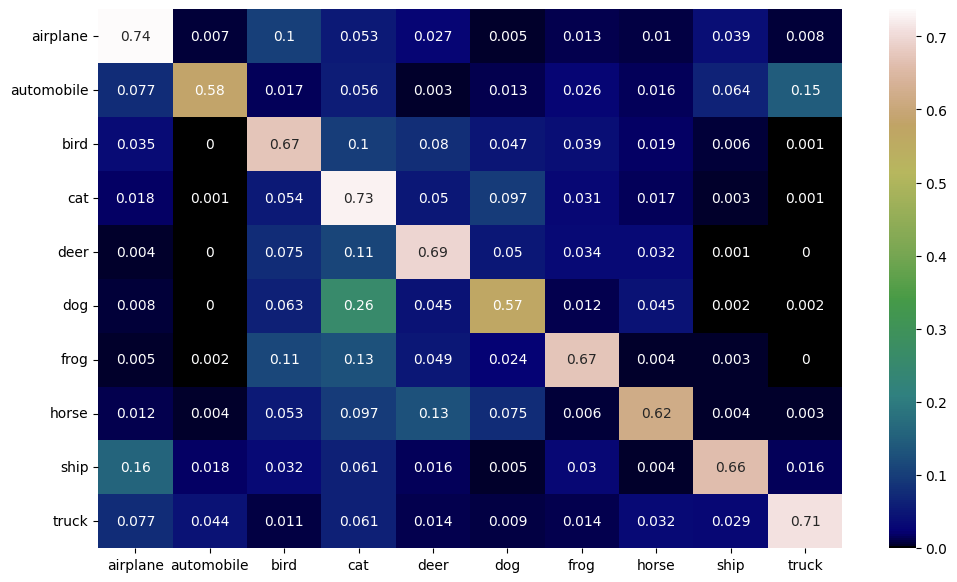

In [68]:

plt.figure(figsize = (30 , 10))
# Concatenate y_true (list of tensors) into a single tensor and convert to numpy
y_true_tensor = torch.cat(y_true).cpu().numpy()
# y_pred_tensor is already defined as torch.cat(model_pred) in the previous cell, convert it to numpy
y_pred_tensor_np = y_pred_tensor.cpu().numpy()

cf_matrix = confusion_matrix(y_true_tensor, y_pred_tensor_np)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in class_names],
                     columns = [i for i in class_names])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True, cmap ='gist_earth')